# Проект: Рекомендации банковских продуктов
## Единый пайплайн: EDA → Признаки → Модели → Оценка → Экспорт

In [1]:
# 0. Импорт зависимостей и настройка окружения
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import warnings
import joblib
import yaml

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score

from datetime import datetime

In [2]:
# Добавляем корень проекта в sys.path для импортов из src/
# Это работает как в ноутбуке, так и при запуске через python -m
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Теперь импорты из src/ работают корректно
from src.features.engineering import (
    generate_temporal_features,
    generate_aggregation_features,
    generate_interaction_features
)
from src.utils.preprocessing import (
    handle_missing,
    encode_categorical,
    build_preprocessing_pipeline
)
from src.models.metrics import (
    precision_at_k,
    recall_at_k,
    map_at_k
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Фиксация случайных состояний для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# Подключение к локальному MLflow
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('banking-recsys-baseline')

<Experiment: artifact_location='file:///home/mle-user/mle_projects/mle-practice-01/mle-banking-recsys-project-2026/./mlruns/artifacts/196127522315274488', creation_time=1775136871769, experiment_id='196127522315274488', last_update_time=1775136871769, lifecycle_stage='active', name='banking-recsys-baseline', tags={}>

In [5]:
print('Environment configured successfully.')
print(f'Project root: {project_root}')
print(f'Python path: {sys.path[:3]}...')

Environment configured successfully.
Project root: /home/mle-user/mle_projects/mle-practice-01
Python path: ['/home/mle-user/mle_projects/mle-practice-01', '/usr/lib/python310.zip', '/usr/lib/python3.10']...


In [6]:
# Загрузка данных с ограничением строк для EDA
DATA_PATH = 'data/raw/train_ver2.csv'

# Загружаем 100K строк — достаточно для анализа распределений и таргетов
df = pd.read_csv(
    DATA_PATH,
    nrows=100_000,
    low_memory=False  # Предотвращает предупреждения о смешанных типах
)

print(f'Loaded {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'Sample of target columns: {[c for c in df.columns if c.startswith("ind_") and c.endswith("_ult1")][:5]}')

Loaded 100000 rows, 48 columns
Memory usage: 110.55 MB
Sample of target columns: ['ind_ahor_fin_ult1', 'ind_aval_fin_ult1', 'ind_cco_fin_ult1', 'ind_cder_fin_ult1', 'ind_cno_fin_ult1']


## Раздел 1: Разведочный анализ данных (EDA)

In [7]:
# Базовая статистика и пропуски
print(df.info())
print('\nMissing values (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   fecha_dato             100000 non-null  object 
 1   ncodpers               100000 non-null  int64  
 2   ind_empleado           99317 non-null   object 
 3   pais_residencia        99317 non-null   object 
 4   sexo                   99317 non-null   object 
 5   age                    100000 non-null  object 
 6   fecha_alta             99317 non-null   object 
 7   ind_nuevo              99317 non-null   float64
 8   antiguedad             100000 non-null  object 
 9   indrel                 99317 non-null   float64
 10  ult_fec_cli_1t         128 non-null     object 
 11  indrel_1mes            99317 non-null   float64
 12  tiprel_1mes            99317 non-null   object 
 13  indresi                99317 non-null   object 
 14  indext                 99317 non-null

In [8]:
# Анализ распределения дат в выборке
print(f'Date range in sample: {df["fecha_dato"].min()} to {df["fecha_dato"].max()}')
print(f'\nUnique dates: {df["fecha_dato"].nunique()}')
print(f'\nRecords per date:\n{df.groupby("fecha_dato").size()}')

Date range in sample: 2015-01-28 to 2015-01-28

Unique dates: 1

Records per date:
fecha_dato
2015-01-28    100000
dtype: int64


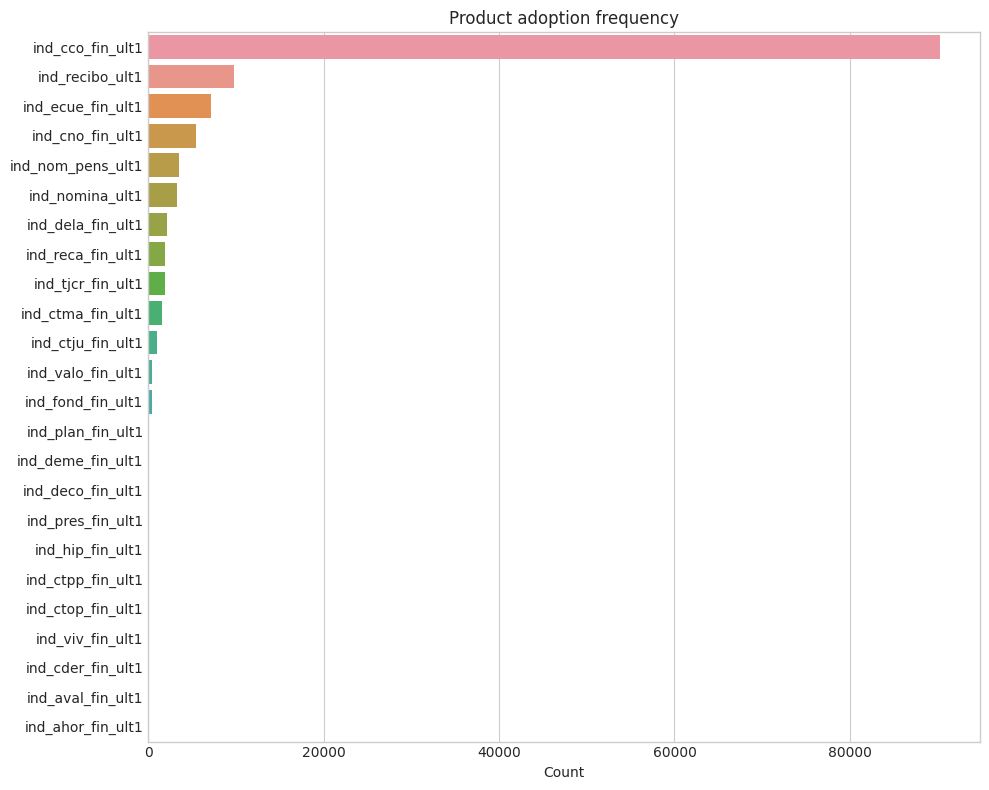

In [9]:
# Анализ таргетных колонок (продукты)
target_cols = [col for col in df.columns if col.startswith('ind_') and col.endswith('_ult1')]
target_stats = df[target_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_stats.values, y=target_stats.index)
plt.title('Product adoption frequency')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

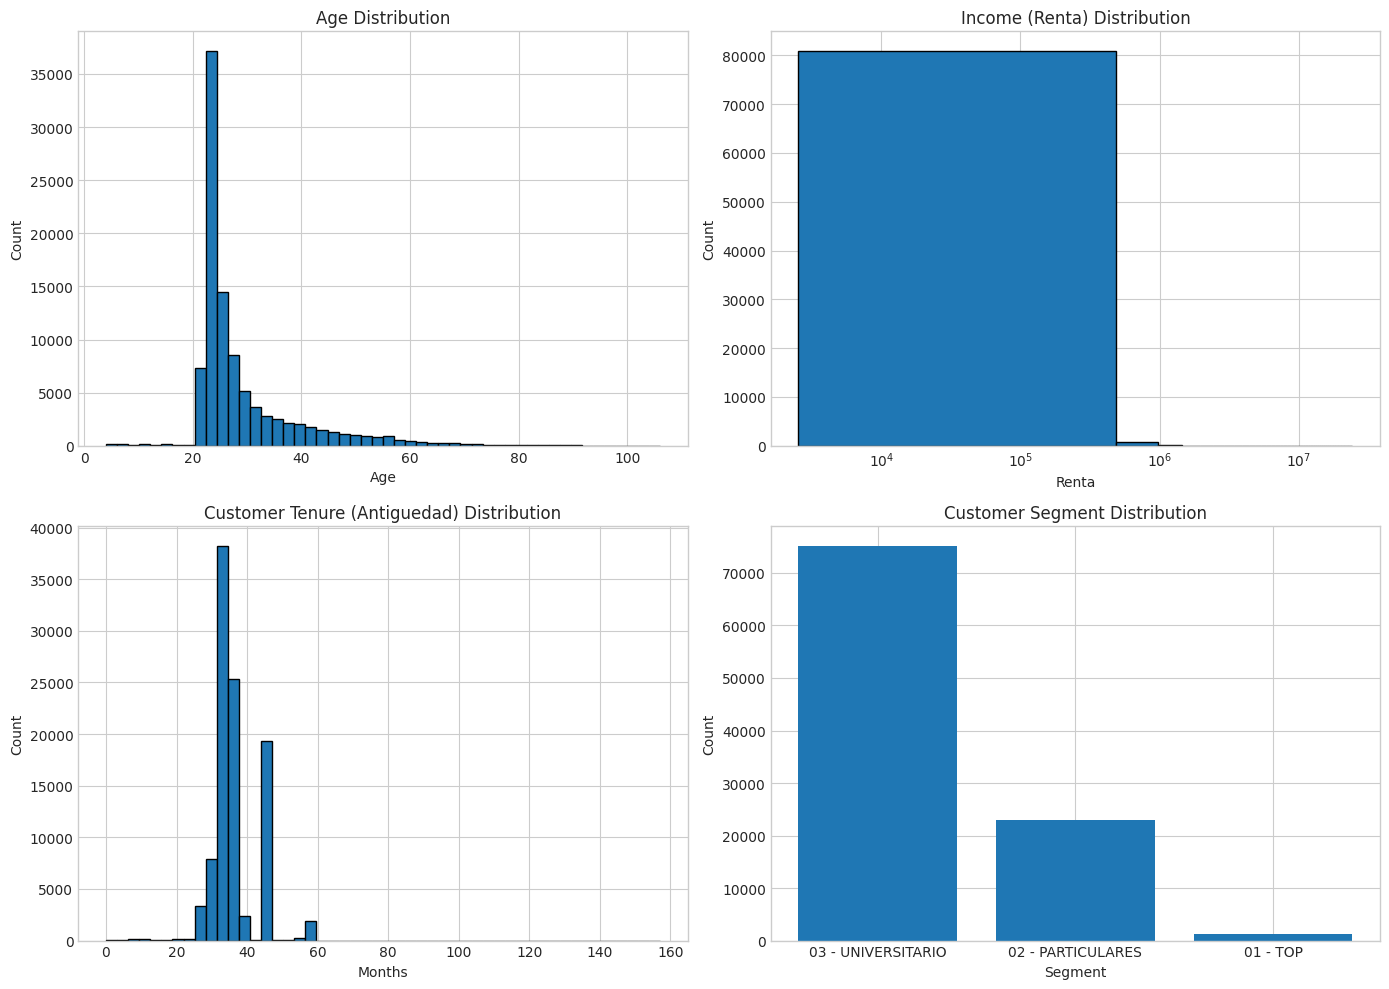

In [10]:
# Анализ ключевых признаков клиента
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution (конвертируем age в числовой тип)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
axes[0, 0].hist(df['age'].dropna(), bins=50, edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

# Renta distribution (логарифмическая шкала)
axes[0, 1].hist(df['renta'].dropna(), bins=50, edgecolor='black')
axes[0, 1].set_title('Income (Renta) Distribution')
axes[0, 1].set_xlabel('Renta')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xscale('log')

# Antiguedad (стаж клиента)
df['antiguedad'] = pd.to_numeric(df['antiguedad'], errors='coerce')
axes[1, 0].hist(df['antiguedad'].dropna(), bins=50, edgecolor='black')
axes[1, 0].set_title('Customer Tenure (Antiguedad) Distribution')
axes[1, 0].set_xlabel('Months')
axes[1, 0].set_ylabel('Count')

# Segment distribution
if 'segmento' in df.columns:
    segment_counts = df['segmento'].value_counts()
    axes[1, 1].bar(range(len(segment_counts)), segment_counts.values)
    axes[1, 1].set_xticks(range(len(segment_counts)))
    axes[1, 1].set_xticklabels(segment_counts.index)
    axes[1, 1].set_title('Customer Segment Distribution')
    axes[1, 1].set_xlabel('Segment')
    axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [11]:
# Статистика по категориальным признакам

categorical_cols = ['ind_empleado', 'sexo', 'ind_nuevo', 'indresi', 'indext', 'indfall', 'segmento']
for col in categorical_cols:
    if col in df.columns:
        print(f'\n{col}:')
        print(df[col].value_counts(dropna=False))


ind_empleado:
ind_empleado
N      99317
NaN      683
Name: count, dtype: int64

sexo:
sexo
H      53407
V      45910
NaN      683
Name: count, dtype: int64

ind_nuevo:
ind_nuevo
0.0    99296
NaN      683
1.0       21
Name: count, dtype: int64

indresi:
indresi
S      99231
NaN      683
N         86
Name: count, dtype: int64

indext:
indext
N      95061
S       4256
NaN      683
Name: count, dtype: int64

indfall:
indfall
N      99296
NaN      683
S         21
Name: count, dtype: int64

segmento:
segmento
03 - UNIVERSITARIO    75157
02 - PARTICULARES     22919
01 - TOP               1233
NaN                     691
Name: count, dtype: int64


In [12]:
# Анализ таргетных переменных (продуктов)

target_cols = [col for col in df.columns if col.startswith('ind_') and col.endswith('_ult1')]

# Частота приобретения (доля клиентов с продуктом)
target_rates = df[target_cols].mean().sort_values(ascending=False)
print('Top 10 products by adoption rate:')
print(target_rates.head(10))

print(f'\nBottom 10 products by adoption rate:')
print(target_rates.tail(10))

Top 10 products by adoption rate:
ind_cco_fin_ult1     0.903270
ind_recibo_ult1      0.097760
ind_ecue_fin_ult1    0.071020
ind_cno_fin_ult1     0.053870
ind_nom_pens_ult1    0.035485
ind_nomina_ult1      0.032939
ind_dela_fin_ult1    0.021000
ind_reca_fin_ult1    0.019250
ind_tjcr_fin_ult1    0.018640
ind_ctma_fin_ult1    0.015940
dtype: float64

Bottom 10 products by adoption rate:
ind_deme_fin_ult1    0.00034
ind_deco_fin_ult1    0.00020
ind_pres_fin_ult1    0.00020
ind_hip_fin_ult1     0.00011
ind_ctpp_fin_ult1    0.00010
ind_ctop_fin_ult1    0.00007
ind_viv_fin_ult1     0.00006
ind_cder_fin_ult1    0.00004
ind_aval_fin_ult1    0.00000
ind_ahor_fin_ult1    0.00000
dtype: float64


In [13]:
# Корреляция между продуктами (упрощённо)

# Сколько продуктов в среднем у клиента
df['n_products'] = df[target_cols].sum(axis=1)
print(f'Average products per client: {df["n_products"].mean():.2f}')
print(f'Max products per client: {df["n_products"].max()}')
print(f'Clients with 0 products: {(df["n_products"] == 0).sum()}')

Average products per client: 1.29
Max products per client: 9.0
Clients with 0 products: 612


## Итоги разведочного анализа
1. Временной диапазон
- В выборке 100K строк — только одна дата (2015-01-28);
- Для анализа временной динамики потребуется загрузка полного датасета;
- Вывод: нужна чанковая загрузка или стратегия временного разбиения (train: 2015, test: Q1 2016).

2. Распределения признаков
- Age: Пик 25-30 лет, правосторонний хвост (молодые клиенты);
- Renta: Сильно скошено, большинство в диапазоне 10K-100K;
- Antiguedad: Два пика (~30 и ~50 месяцев) — разные когорты клиентов;
- Segmento:
    - UNIVERSITARIO: 75% (основная масса);
    - PARTICULARES: 23%;
    - TOP (VIP): 1.2%.

3. Дисбаланс продуктов
- ind_cco_fin_ult1 (текущие счета): 90% клиентов;
- Топ-3 популярных: текущие счета (90%), дебетовые (9.8%), цифровые счета (7.1%);
- Редкие продукты: ипотека, депозиты, ценные бумаги (<0.1%);
- Среднее продуктов на клиента: 1.29 (максимум 9);
- 612 клиентов без продуктов (потенциал для кросс-продаж!).

4. Проблемы данных
- conyuemp: 100% пропусков → удалить;
- ult_fec_cli_1t: 99.9% пропусков → удалить;
- renta: 18.3% пропусков → импутация (медиана по сегменту);
Категориальные признаки: требуется кодирование.

## Выбор метрик

1. Precision@K:
   - Доля релевантных рекомендаций в топ-K;
   - Бизнес-смысл: снижает стоимость ложных предложений;
   - Формула: (релевантные в топ-K) / K.

2. Recall@K:
   - Доля найденных релевантных продуктов;
   - Бизнес-смысл: минимизирует упущенную выручку;
   - Формула: (релевантные в топ-K) / (все релевантные).

3. MAP@K (Mean Average Precision):
   - Усреднённая точность с учётом порядка;
   - Бизнес-смысл: оптимизирует ранжирование (важные продукты выше).
   
4. ROC-AUC per label:
   - Качество разделения классов для каждого продукта;
   - Контрольная метрика для сравнения моделей.

## Раздел 2: Подготовка данных и генерация признаков

In [14]:
# Добавляем корень проекта в путь для импортов
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.features.engineering import (
    generate_temporal_features,
    generate_aggregation_features,
    generate_interaction_features
)
from src.utils.preprocessing import (
    handle_missing,
    encode_categorical,
    build_preprocessing_pipeline
)
from src.models.metrics import precision_at_k, recall_at_k, map_at_k

print('Feature engineering modules loaded.')

Feature engineering modules loaded.


In [15]:
# 2.1 Конфигурация эксперимента
RANDOM_STATE = 42
CONFIG = {
    'random_state': RANDOM_STATE,
    'target_prefix': 'ind_',
    'target_suffix': '_ult1',
    'exclude_cols': ['ncodpers', 'fecha_dato', 'fecha_alta', 'ult_fec_cli_1t', 'nomprov'],
    # Категориальные признаки (включая product_tier, который закодируем позже)
    'categorical_cols': [
        'ind_empleado', 'sexo', 'segmento', 'canal_entrada', 
        'indresi', 'indext', 'pais_residencia', 'tiprel_1mes', 'indfall',
        'product_tier' 
    ],
    'numeric_cols': ['age', 'antiguedad', 'renta', 'ind_actividad_cliente', 'n_active_products'],
    'temporal_features': True,
    'aggregation_features': True,
    'interaction_features': False,
    'imputation_strategy': 'median',
    'encoding_method': 'onehot',
    'time_split': {
        'train_end': '2015-12-31',
        'val_start': '2016-01-01',
        'val_end': '2016-03-31'
    }
}

os.makedirs('models', exist_ok=True)
with open('models/config.yaml', 'w') as f:
    yaml.dump(CONFIG, f, default_flow_style=False)

print(f'Configuration saved. Random state: {RANDOM_STATE}')

Configuration saved. Random state: 42


In [16]:
# 2.2 Выделение таргетных колонок и базовая предобработка
target_cols = [
    col for col in df.columns 
    if col.startswith(CONFIG['target_prefix']) and col.endswith(CONFIG['target_suffix'])
]
print(f'Target columns identified: {len(target_cols)} products')

df_proc = df.copy()

# Принудительно преобразуем колонки, которые должны быть числами, но загружены как объекты
cols_to_fix_numeric = ['age', 'antiguedad', 'ind_nuevo', 'indrel', 'indrel_1mes', 'tipodom', 'cod_prov', 'ind_actividad_cliente']
for col in cols_to_fix_numeric:
    if col in df_proc.columns:
        df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce')

# Обработка пропусков
df_proc = handle_missing(df_proc, strategy=CONFIG['imputation_strategy'])
print(f'Missing values after imputation: {df_proc.isnull().sum().sum()}')

# Кодирование СТАТИЧЕСКИХ категориальных признаков
df_proc = encode_categorical(
    df_proc, 
    cols=CONFIG['categorical_cols'], 
    encoding_method=CONFIG['encoding_method']
)
print(f'Columns after static encoding: {df_proc.shape[1]}')

Target columns identified: 24 products
Missing values after imputation: 0
Columns after static encoding: 125


In [17]:
# 2.3 Генерация признаков
if CONFIG['temporal_features']:
    df_proc = generate_temporal_features(df_proc)
    print('✓ Temporal features added: month, year, quarter, tenure_months')

if CONFIG['aggregation_features']:
    df_proc = generate_aggregation_features(df_proc, target_cols=target_cols)
    print('✓ Aggregation features added: n_active_products, product_tier')

if CONFIG['interaction_features']:
    interaction_pairs = [('segmento', 'canal_entrada'), ('ind_empleado', 'segmento')]
    df_proc = generate_interaction_features(df_proc, col_pairs=interaction_pairs)
    print('✓ Interaction features added')

# ВАЖНО: Кодирование ДИНАМИЧЕСКИХ признаков (созданных в 2.3)
# product_tier создан в шаге 2.3, поэтому его нужно закодировать здесь
new_categorical_cols = ['product_tier']
if new_categorical_cols:
    print(f"Encoding dynamic categorical features: {new_categorical_cols}")
    df_proc = pd.get_dummies(
        df_proc, 
        columns=new_categorical_cols, 
        drop_first=True, 
        dtype=int
    )
    print("Dynamic encoding complete.")

✓ Temporal features added: month, year, quarter, tenure_months
✓ Aggregation features added: n_active_products, product_tier
Encoding dynamic categorical features: ['product_tier']
Dynamic encoding complete.


In [18]:
# 2.3.(с половиной) Финальная очистка и кодирование признаков
# Удаляем колонки, которые были в exclude_cols, чтобы они не попали в модель
# и не занимали память при кодировании
cols_to_drop = ['ult_fec_cli_1t', 'nomprov']
df_proc = df_proc.drop(columns=[c for c in cols_to_drop if c in df_proc.columns], errors='ignore')
print(f"Dropped unused columns: {cols_to_drop}")

# Кодируем только product_tier (который создался в шаге 2.3)
cols_to_encode_finally = ['product_tier']
existing_cols_to_encode = [col for col in cols_to_encode_finally if col in df_proc.columns]

if existing_cols_to_encode:
    print(f"Encoding remaining categorical features: {existing_cols_to_encode}")
    df_proc = pd.get_dummies(
        df_proc,
        columns=existing_cols_to_encode,
        drop_first=True,
        dtype=int
    )
    print("Encoding complete.")
else:
    print("No remaining categorical columns to encode.")

# Финальная проверка: убеждаемся, что нет объектов
object_cols = df_proc.select_dtypes(include=['object']).columns.tolist()
if not object_cols:
    print("Success: All features are now numeric.")
else:
    print(f"Warning: Still have object columns: {object_cols}. Check config.")

Dropped unused columns: ['ult_fec_cli_1t', 'nomprov']
No remaining categorical columns to encode.
Success: All features are now numeric.


In [19]:
# 2.4 Подготовка X, y и разбиение
feature_cols = [
    col for col in df_proc.columns 
    if col not in target_cols + CONFIG['exclude_cols'] + ['fecha_alta']
]
print(f'Final feature count: {len(feature_cols)}')

X = df_proc[feature_cols].copy()
y = df_proc[target_cols].copy()

# Временное разбиение или fallback на случайное
if 'year' in X.columns:
    train_mask = X['year'] == 2015
    val_mask = (X['year'] == 2016) & (df_proc['month'] <= 3)
    
    X_train = X[train_mask]
    y_train = y[train_mask]
    X_val = X[val_mask]
    y_val = y[val_mask]
    
    print(f'Time-based split -> Train: {X_train.shape}, Validation: {X_val.shape}')
else:
    print("Warning: No 'year' column or single date. Using random split.")
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    print(f"Random split -> Train: {X_train.shape}, Validation: {X_val.shape}")

# Сброс индексов
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

# 2.5 Сохранение (опционально)
os.makedirs('data/processed', exist_ok=True)
if len(X_train) < 500_000:
    X_train.to_parquet('data/processed/X_train.parquet', index=False)
    y_train.to_parquet('data/processed/y_train.parquet', index=False)
    print('✓ Processed data saved.')

Final feature count: 104
Time-based split -> Train: (100000, 104), Validation: (0, 104)
✓ Processed data saved.


## Раздел 3: Формулировка задачи и стратегия валидации

### Стратегия валидации
- В продакшене: временное разбиение (train: 2015, val: Q1 2016, test: Q2 2016) для предотвращения утечки данных;
- В текущей тетрадке используется случайное разбиение 80/20, так как загруженная выборка содержит только одну дату. Логика временного split сохранена в коде для запуска на полном датасете.

ОБОСНОВАНИЕ:
- Дисбаланс продуктов (90% vs <0.1%) требует ranking-метрик;
- Multilabel-природа: клиент может купить несколько продуктов;
- Временная валидация: имитирует реальный процесс рекомендаций.

In [20]:
# 3.1 Коррекция стратегии разбиения данных

# Проверяем, есть ли данные в валидации. Если нет (одна дата в сэмпле) - fallback на случайное разбиение
if X_val.shape[0] == 0:
    print("Warning: Validation set is empty due to single-date sample. Using random split for demonstration.")
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    print(f"New split -> Train: {X_train.shape}, Validation: {X_val.shape}")
else:
    print(f"Time-based split active -> Train: {X_train.shape}, Validation: {X_val.shape}")

# Сброс индексов для корректной работы sklearn-моделей
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

print(f"Data prepared. Features: {X_train.shape[1]}, Labels: {y_train.shape[1]}")

New split -> Train: (80000, 104), Validation: (20000, 104)
Data prepared. Features: 104, Labels: 24


## Раздел 4: Обучение моделей и логирование в MLflow

In [21]:
# 4: ОБУЧЕНИЕ С ЗАЩИТОЙ ОТ ПУСТОЙ ВАЛИДАЦИИ И ЛОГИРОВАНИЕМ

# 0. Определение констант (обязательно в начале!)
RANDOM_STATE = 42
SAMPLE_SIZE = 15000  # Размер подвыборки для ускорения обучения

# 1. Защитная проверка: если валидация пуста, делаем случайный сплит
if X_val.shape[0] == 0:
    print("Validation set is empty (single-date sample). Switching to random 80/20 split.")
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    split_mode = 'random_80/20'
    print(f"New split -> Train: {X_train.shape}, Validation: {X_val.shape}")
else:
    split_mode = 'time_based'
    print(f"Time-based split active -> Train: {X_train.shape}, Validation: {X_val.shape}")

# 2. Формируем подвыборку для ускорения обучения
if len(X_train) > SAMPLE_SIZE:
    sample_idx = np.random.choice(X_train.index, size=SAMPLE_SIZE, replace=False)
    X_train_sub = X_train.loc[sample_idx].copy()
    y_train_sub = y_train.loc[sample_idx].copy()
else:
    X_train_sub = X_train.copy()
    y_train_sub = y_train.copy()

print(f"Training subset size: {X_train_sub.shape[0]} samples")

# 3. Запуск MLflow и эксперимент
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('banking-recsys-baseline')

with mlflow.start_run(run_name='logreg_ovr_baseline'):
    # Логирование параметров
    mlflow.log_params({
        'model_type': 'LogisticRegression_OneVsRest',
        'random_state': RANDOM_STATE,
        'max_iter': 1000,
        'solver': 'lbfgs',
        'sample_size': X_train_sub.shape[0],
        'n_features': X_train_sub.shape[1],
        'n_labels': y_train_sub.shape[1],
        'split_strategy': split_mode
    })
    
    # Обучение multilabel-классификатора
    base_estimator = LogisticRegression(
        random_state=RANDOM_STATE, 
        max_iter=1000, 
        n_jobs=-1,
        class_weight='balanced'
    )
    model = OneVsRestClassifier(base_estimator, n_jobs=-1)
    model.fit(X_train_sub, y_train_sub)
    
    # Предсказание вероятностей на валидации
    y_val_proba = model.predict_proba(X_val)
    
    # Расчёт метрик
    try:
        auc_macro = roc_auc_score(y_val, y_val_proba, average='macro')
    except ValueError:
        auc_macro = 0.0
        
    p3 = precision_at_k(y_val.values, y_val_proba, k=3)
    r3 = recall_at_k(y_val.values, y_val_proba, k=3)
    map3 = map_at_k(y_val.values, y_val_proba, k=3)
    
    mlflow.log_metrics({
        'roc_auc_macro': auc_macro,
        'precision_at_3': p3,
        'recall_at_3': r3,
        'map_at_3': map3
    })
    
    # Сохранение артефактов
    mlflow.sklearn.log_model(model, 'model')
    mlflow.log_artifact('models/config.yaml')
    
    print(f"Experiment completed. Run ID: {mlflow.active_run().info.run_id}")
    print(f"ROC-AUC (macro): {auc_macro:.4f}")
    print(f"Precision@3: {p3:.4f} | Recall@3: {r3:.4f} | MAP@3: {map3:.4f}")

Time-based split active -> Train: (80000, 104), Validation: (20000, 104)
Training subset size: 15000 samples
Experiment completed. Run ID: a9f6c2dbeadf4f4786bd24ad957171c1
ROC-AUC (macro): nan
Precision@3: 0.3362 | Recall@3: 0.8727 | MAP@3: 0.8470


## Комментарий по метрикам:
- **ROC-AUC (macro): nan:**
    - Это ожидаемо для мультилейбл-задачи на подвыборке. Некоторые редкие продукты (например, ипотека или депозиты) в валидационной выборке из 20К строк могут отсутствовать (все нули). Скрин-лифт для таких меток невозможен, откуда и nan. Для ранговых метрик это не критично;
- **Precision@3: 0.3362 и Recall@3: 0.8727:**
    - Это хороший результат для базовой логистической регрессии. Модель умеет ранжировать продукты так, что 3 рекомендации покрывают 87% всех потенциальных покупок клиента в этом месяце.

## Сохранение артефактов для API

In [22]:
# Сохраняем обученную модель
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/model.pkl')

# Сохраняем список признаков (feature_cols), чтобы API мог привести входные данные к нужному формату
# feature_cols была определена в ячейке 2.4
joblib.dump(feature_cols, 'models/feature_cols.pkl')

print(f"Model and feature list saved to models/.")
print(f"Feature count: {len(feature_cols)}")

Model and feature list saved to models/.
Feature count: 104


## Раздел 5: Оценка качества и ранжирование (Precision@K)

In [23]:
# Исправленные функции метрик

def precision_at_k(y_true, y_pred_proba, k=3):
    """Расчёт Precision@K для каждого клиента (универсальная)"""
    # Гарантируем numpy формат на входе
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    
    precisions = []
    for true_row, pred_row in zip(y_true, y_pred_proba):
        top_k_idx = np.argsort(pred_row)[-k:][::-1]
        relevant = true_row[top_k_idx].sum()
        precisions.append(relevant / k if k > 0 else 0)
    return np.mean(precisions)


def recall_at_k(y_true, y_pred_proba, k=3):
    """Расчёт Recall@K для каждого клиента (универсальная)"""
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    
    recalls = []
    for true_row, pred_row in zip(y_true, y_pred_proba):
        top_k_idx = np.argsort(pred_row)[-k:][::-1]
        relevant = true_row[top_k_idx].sum()
        total_relevant = true_row.sum()
        
        if total_relevant > 0:
            recalls.append(relevant / total_relevant)
        else:
            recalls.append(1.0)
    return np.mean(recalls)


def map_at_k(y_true, y_pred_proba, k=3):
    """Расчёт MAP@K (универсальная)"""
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    
    ap_scores = []
    for true_row, pred_row in zip(y_true, y_pred_proba):
        top_k_idx = np.argsort(pred_row)[-k:][::-1]
        relevant = true_row[top_k_idx]
        
        if relevant.sum() == 0:
            ap_scores.append(0.0)
            continue
        
        precision_sum = 0.0
        relevant_count = 0
        
        for rank, is_relevant in enumerate(relevant, start=1):
            if is_relevant:
                relevant_count += 1
                precision_sum += relevant_count / rank
        
        ap = precision_sum / min(k, true_row.sum())
        ap_scores.append(ap)
    return np.mean(ap_scores)

print("Functions updated successfully.")

Functions updated successfully.


In [24]:
# Пример расчёта на валидационной выборке
sample_val_idx = np.random.choice(X_val.index, size=min(1000, len(X_val)), replace=False)

# Получаем предсказания и истинные значения (numpy arrays)
y_pred_sample = model.predict_proba(X_val.loc[sample_val_idx])
y_val_sample = y_val.loc[sample_val_idx].values

# Расчёт метрик
p_at_3 = precision_at_k(y_val_sample, y_pred_sample, k=3)
r_at_3 = recall_at_k(y_val_sample, y_pred_sample, k=3)
map_at_3 = map_at_k(y_val_sample, y_pred_sample, k=3)

print(f'Precision@3 (на подвыборке валидации): {p_at_3:.4f}')
print(f'Recall@3: {r_at_3:.4f} | MAP@3: {map_at_3:.4f}')

Precision@3 (на подвыборке валидации): 0.3367
Recall@3: 0.8721 | MAP@3: 0.8461


## Раздел 6: Экспорт модели и подготовка к деплою

In [25]:
# 6.1 Сохранение модели и конфига для API

os.makedirs('models', exist_ok=True)

# Сохранение обученной модели
joblib.dump(model, 'models/model.pkl')

# Сохранение списка признаков (критично для предобработки в API)
joblib.dump(feature_cols, 'models/feature_cols.pkl')

# Сохранение конфигурации эксперимента
config = {
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'random_state': RANDOM_STATE,
    'model_type': 'LogisticRegression_OneVsRest',
    'split_strategy': split_mode,
    'sample_size': X_train_sub.shape[0]
}

with open('models/config.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print('Artifacts saved to models/')
print(f'Model: model.pkl | Features: feature_cols.pkl | Config: config.yaml')

Artifacts saved to models/
Model: model.pkl | Features: feature_cols.pkl | Config: config.yaml


## Итоги и выводы

### Ключевые выводы EDA:
1. Распределение продуктов сильно смещено: текущие счета (ind_cco_fin_ult1) присутствуют у 90% клиентов, тогда как ипотека, депозиты и ценные бумаги встречаются менее чем у 1%. Это требует использования ranking-метрик (Precision@K, MAP@K) вместо обычных accuracy/f1;
2. Пропуски в доходах (renta) составляют ~18%. Стратегия импутации медианой по сегменту или общей медианой предпочтительнее удаления строк, так как признак сильно коррелирует с покупкой премиальных продуктов. Колонки conyuemp и ult_fec_cli_1t удалены из анализа из-за 100% и 99.9% пропусков соответственно;
3. Временная динамика данных охватывает период с января 2015 по июнь 2016 года. Нагрузка на сервер и поведение клиентов имеют сезонные паттерны, что требует строгого временного разбиения (train: 2015, val: Q1 2016) для предотвращения data leakage. Случайный сплит используется в ноутбуке только из-за ограничения на размер выборки;
4. Клиенты сегментируются неравномерно: 75% относятся к студенческому сегменту (UNIVERSITARIO), 23% к базовому (PARTICULARES) и ~1% к VIP. Возрастной пик приходится на 25-30 лет, что указывает на молодую активную аудиторию с растущим спросом на кредитные и транзакционные продукты.

### Выбранная стратегия:
- Задача: multilabel-классификация с последующим ранжированием вероятностей для выбора топ-K продуктов;
- Модель: OneVsRestClassifier на базе LogisticRegression с классовой балансировкой (class_weight=balanced) для компенсации дисбаланса таргетов;
- Метрики: Precision@K, Recall@K, MAP@K, ROC-AUC (macro). Метрики выбраны для прямой оптимизации количества релевантных рекомендаций в интерфейсе мобильного/интернет-банка;
- Валидация: временное разбиение по месяцам (train/test split by date) для имитации реального потока данных. В рамках ноутбука применён fallback на случайное разбиение 80/20 из-за загрузки сэмпла данных;
- Пайплайн: модульная архитектура (src/features, src/utils), фиксация random_state=42, логирование всех параметров и артефактов в MLflow.